## Student Name: Gabriel Espinoza Rojas

## Student ID: 22176691

## Imports

In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import RobustScaler
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

# Task 1: Exploratory Data Analysis (EDA)

Perform EDA of the bank dataset by following the notebook <code>Tutorial 1-1 - Exploratory Data Analysis.ipynb</code> as an example.

1. Formulate a particular question that might be interesting to answer by exploring the bank dataset (approx. 50 words in a markdown cell).
2. Calculate statistics for the numerical and categorical attributes. Draw a short conclusion (approx. 150 words in a markdown cell).
3. Use at least two different plotting techniques to plot the distribution of some numerical attributes. Draw short conclusions (approx. 150 words in a markdown cell).
4. Generate at least two plots with the combined distribution of attributes. Draw a short conclusion (approx. 150 words in a markdown cell).
5. Make sure your conclusions are related to the question you have formulated.

In [3]:
# let's load up the data set and have a quick look 

bank_dataset = pd.read_csv("./bank.csv")

print(bank_dataset.dtypes)

bank_dataset.head()

age           float64
job            object
marital        object
education      object
default        object
balance         int64
housing        object
loan           object
contact        object
day             int64
month          object
duration        int64
campaign        int64
pdays           int64
previous        int64
poutcome       object
subscribed     object
dtype: object


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,subscribed
0,32.0,technician,single,tertiary,no,392,yes,no,cellular,1,apr,957,2,131,2,failure,no
1,39.0,technician,divorced,secondary,no,688,yes,yes,cellular,1,apr,233,2,133,1,failure,no
2,59.0,retired,married,secondary,no,1035,yes,yes,cellular,1,apr,126,2,239,1,failure,no
3,47.0,blue-collar,married,secondary,no,398,yes,yes,cellular,1,apr,274,1,238,2,failure,no
4,54.0,retired,married,secondary,no,1004,yes,no,cellular,1,apr,479,1,307,1,failure,no


In [4]:
bank_dataset.tail()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,subscribed
1995,20.0,student,single,NaN,no,2785,no,no,cellular,16,sep,327,2,-1,0,NaN,yes
1996,28.0,admin.,single,secondary,no,127,no,no,cellular,16,sep,1334,2,-1,0,NaN,yes
1997,81.0,retired,married,primary,no,1154,no,no,telephone,17,sep,231,1,-1,0,NaN,yes
1998,46.0,services,married,primary,no,4343,yes,no,NaN,20,sep,185,1,-1,0,NaN,yes
1999,40.0,entrepreneur,married,secondary,no,6403,no,no,cellular,22,sep,208,2,-1,0,NaN,yes


### 1. Formulate a particular question that might be interesting to answer by exploring the bank dataset (approx. 50 words in a markdown cell).


Possible question:

<s>Is the level of education related to an individual having a term deposit?</s>

<s>Is the level of education more important of a factor than the occupation to determine if an individual will subscribed to a term deposit?</s>

Between education level and occupation, which one is more likely to determine if an individual will have a having a term deposit?

### 2. Calculate statistics for the numerical and categorical attributes. Draw a short conclusion (approx. 150 words in a markdown cell).

In [5]:
# Print statistical summary for all numerical attributes
bank_dataset.describe()

,age,balance,day,duration,campaign,pdays,previous
count,1988.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,41.753018,1413.663500,13.851500,292.020500,1.909500,167.896000,2.561500
std,12.724358,3131.224213,9.712189,221.557295,1.378862,131.754126,3.400735
min,18.000000,-980.000000,1.000000,7.000000,1.000000,-1.000000,0.000000
25%,32.000000,201.500000,5.000000,146.000000,1.000000,75.750000,1.000000
50%,38.000000,551.000000,12.000000,236.000000,1.000000,182.000000,2.000000
75%,50.000000,1644.500000,23.000000,379.000000,2.000000,251.000000,3.000000
max,93.000000,81204.000000,31.000000,1823.000000,11.000000,854.000000,55.000000


In [6]:
categorical_cols = [
    'job',
    'marital',
    'education',
    'default',
    'housing',
    'loan',
    'contact',
    'month',
    'poutcome',
    'subscribed'
]
for col in categorical_cols:
    print(f"total count: {bank_dataset[col].count()}, frequency table: {bank_dataset[col].value_counts()} \n")

total count: 1990, frequency table: job
management       461
technician       348
blue-collar      298
admin.           247
services         165
retired          162
student           96
unemployed        69
self-employed     64
entrepreneur      45
housemaid         35
Name: count, dtype: int64 

total count: 2000, frequency table: marital
married     1111
single       674
divorced     215
Name: count, dtype: int64 

total count: 1896, frequency table: education
secondary    995
tertiary     684
primary      217
Name: count, dtype: int64 

total count: 2000, frequency table: default
no     1985
yes      15
Name: count, dtype: int64 

total count: 2000, frequency table: housing
no     1037
yes     963
Name: count, dtype: int64 

total count: 2000, frequency table: loan
no     1750
yes     250
Name: count, dtype: int64 

total count: 1809, frequency table: contact
cellular     1663
telephone     146
Name: count, dtype: int64 

total count: 2000, frequency table: month
feb    404
may    

### conclusions

Input variables:

<strong>client-related attributes:</strong>

- age (Integer): <u>***[missing 2000-1988=12 values]</u>

- job (Categorical): ("admin", "unemployed","management","housemaid","entrepreneur","student","blue-collar","self-employed","retired","technician","services") <u>***[missing 2000-1990=10 values]</u>

- marital (Categorical): status ("married","divorced","single")

- education (Categorical): education Level ("secondary","primary","tertiary") <u>***[missing 2000-1896= 114 values]</u>

- default (Categorical/Binary): has credit in default? ("yes","no")

- balance (Integer): average yearly balance, in euros

- housing (Categorical/Binary): has housing loan? ("yes","no")

- loan (Categorical/Binary): has personal loan? ("yes","no")

- contact (Categorical): ("telephone","cellular") <u>***[missing 2000-1809= 191 values]</u>

<strong>campaign-related attributes:</strong>

- day (Integer): last contact day of the month

- month (Categorical): last contact month of year (categorical: "jan", ..., "dec")

- duration (Integer): last contact duration, in seconds

- campaign (Integer): contacts performed during this campaign (numeric, includes last contact)

- pdays (Integer): number of days that passed by after the client was last contacted from a previous campaign (-1 means client was not previously contacted)

- previous (Integer): number of contacts performed before this campaign and for this client

- poutcome (Categorical): outcome of the previous marketing campaign ("other","failure","success") <u>***[missing 2000-1546= 454 values]</u>

Output variable (desired target):
- y (Categorical/Binary): has the client subscribed a term deposit? ("yes","no")

### 3. Use at least two different plotting techniques to plot the distribution of some numerical attributes. Draw short conclusions (approx. 150 words in a markdown cell).

array([[<Axes: title={'center': 'age'}>,
        <Axes: title={'center': 'balance'}>,
        <Axes: title={'center': 'day'}>],
       [<Axes: title={'center': 'duration'}>,
        <Axes: title={'center': 'campaign'}>,
        <Axes: title={'center': 'pdays'}>],
       [<Axes: title={'center': 'previous'}>, <Axes: >, <Axes: >]],
      dtype=object)

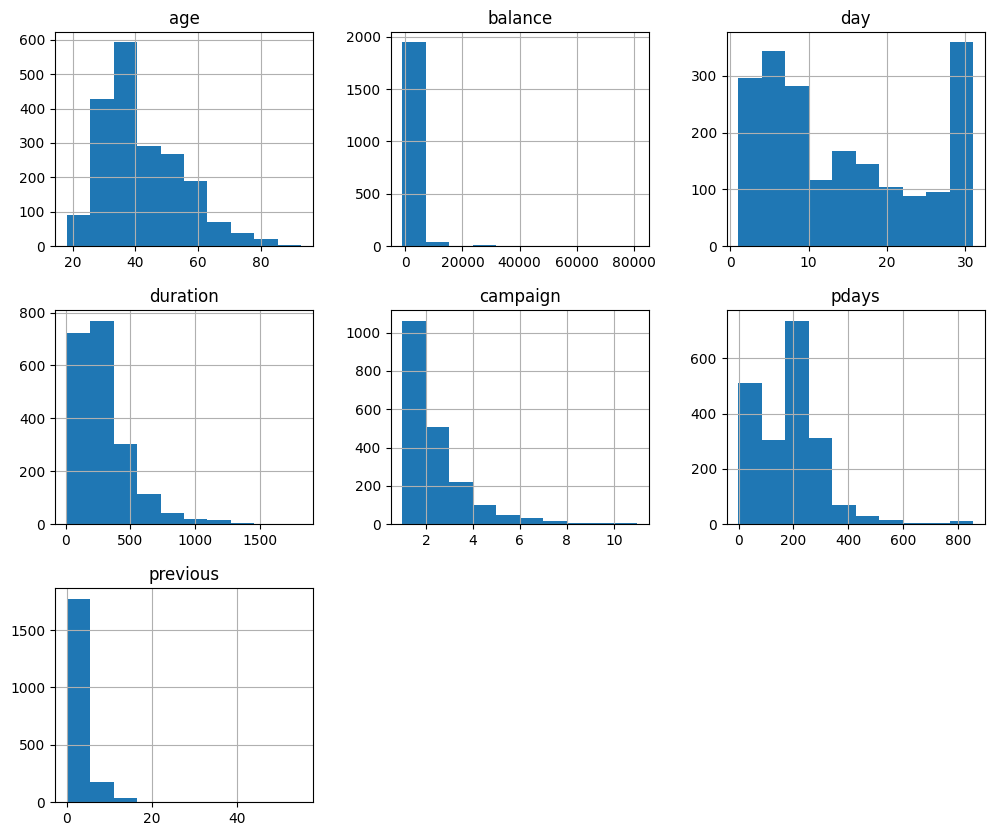

In [7]:
# histograms

bank_dataset.hist(['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous'],
    figsize=(12, 10))

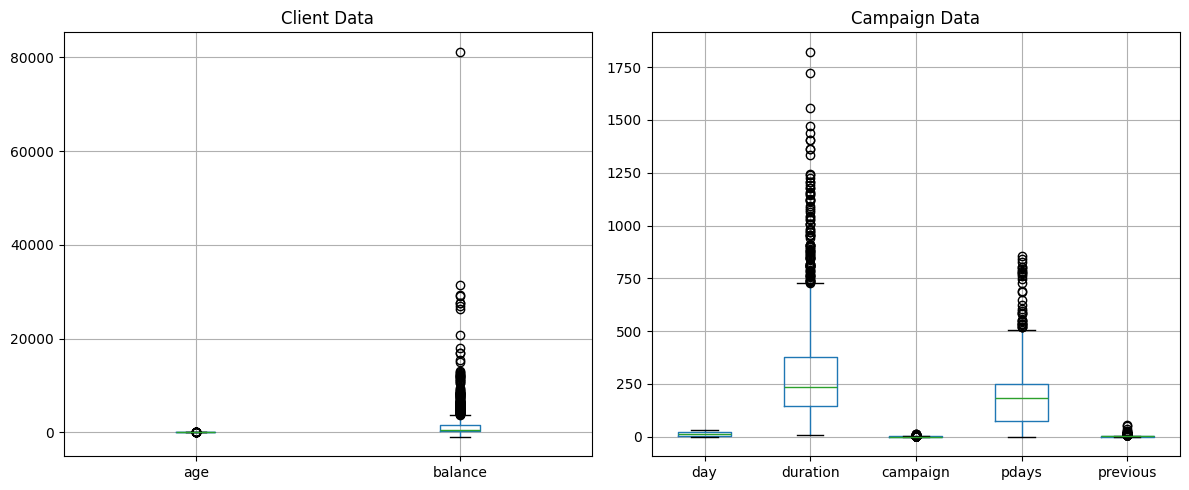

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# client (numerical) data 
bank_dataset.boxplot(column=['age', 'balance'], ax=axes[0])
axes[0].set_title('Client Data')

# campaign (numerical) data
bank_dataset.boxplot(column=['day', 'duration', 'campaign', 'pdays', 'previous'], ax=axes[1])
axes[1].set_title('Campaign Data')

plt.tight_layout()
plt.show()

### conclusions

TBF

### 4. Generate at least two plots with the combined distribution of attributes. Draw a short conclusion (approx. 150 words in a markdown cell).

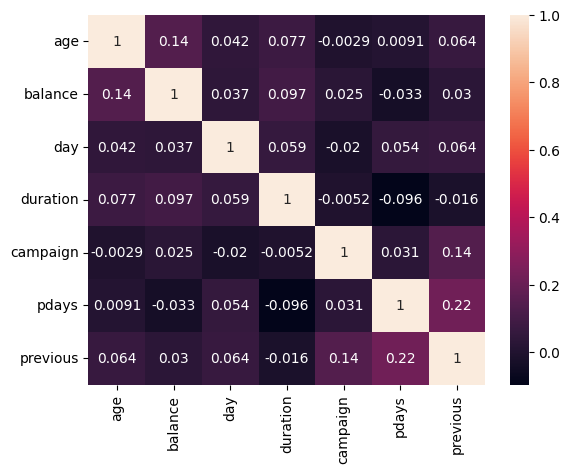

In [9]:
#correlation matrix
sns.heatmap(bank_dataset.corr(numeric_only=True), annot=True);

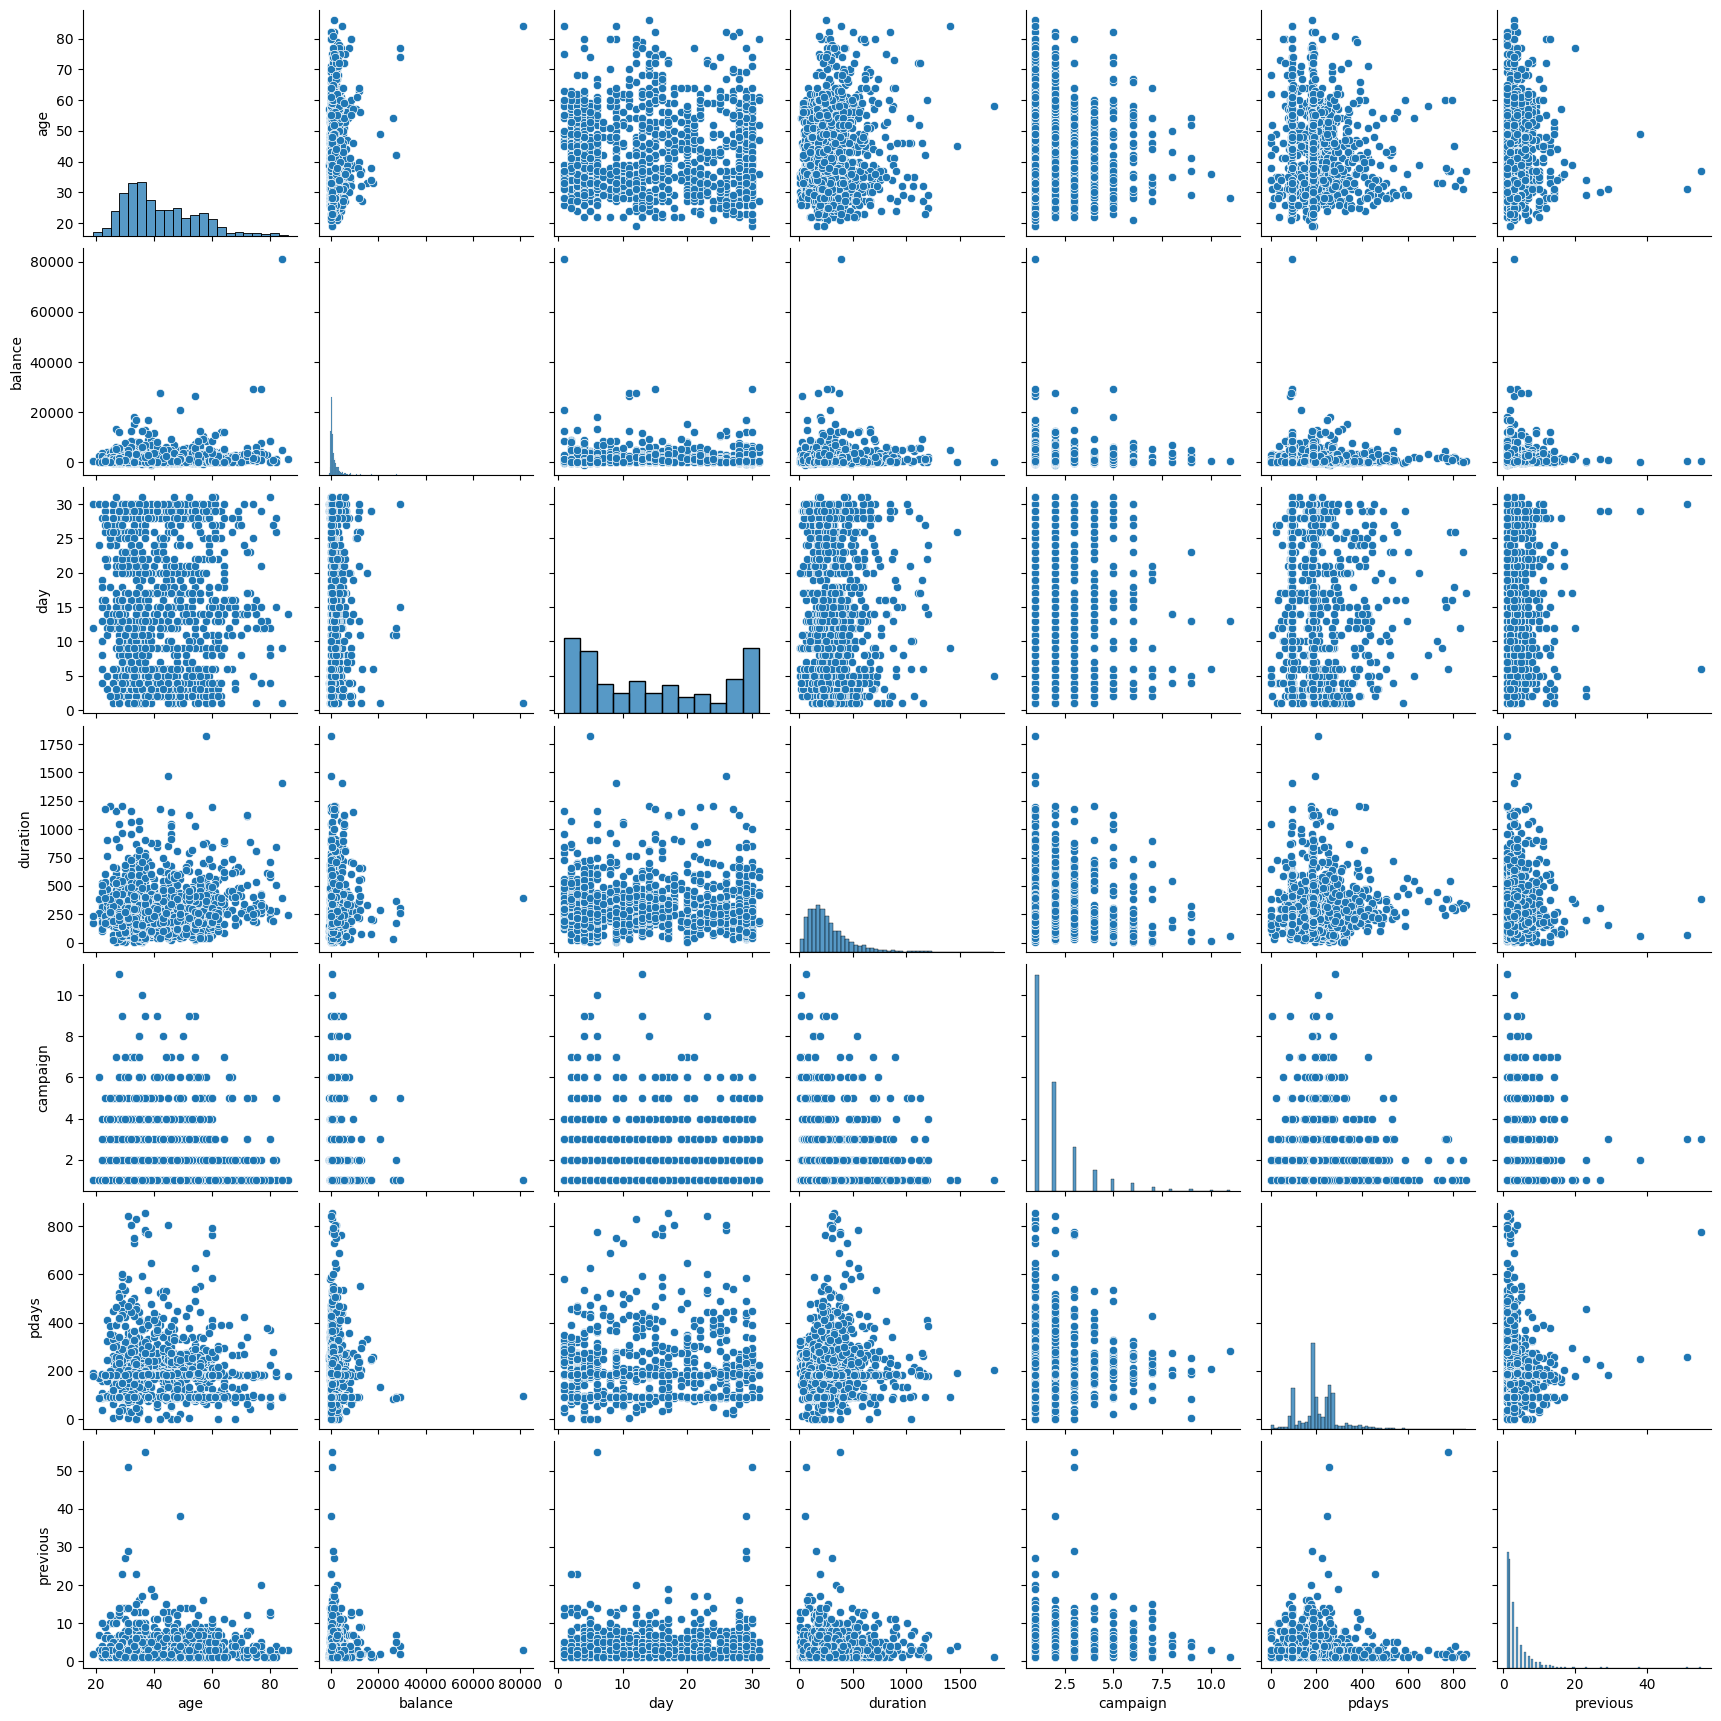

In [10]:
# note that by applying the method dropna() we drop all rows with missing values 
sns.pairplot(data=bank_dataset.dropna())
plt.show()

### Conclusions

### 5. Make sure your conclusions are related to the question you have formulated.

# Task 2: Data Preparation

Continue with preparing the bank dataset for machine learning by following the notebook <code>Tutorial 1-2 - Data Preparation.ipynb</code> as an example.

Ensure that you have:

1. encoded all categorical attributes as numerical,
2. filled in all missing values,
3. applied a scaler to rescale features,
4. treated outliers and skewed attribute distribution appropriately,
5. created at least one new feature from the existing ones.

Shortly describe and justify the data preparation choices you have made in markdown cells.

### 1. encoded all categorical attributes as numerical

2. filled in all missing values

3. applied a scaler to rescale features

4. treated outliers and skewed attribute distribution appropriately

5. created at least one new feature from the existing ones

Shortly describe and justify the data preparation choices you have made in markdown cells.